# fio DFS All-Patterns Analysis

Analyzes `rand_write / rand_read / mixed` and `seq_write / seq_read / mixed` results
across block sizes for a single configuration:

- **nj16/iod16**: numjobs=16, iodepth=16 (256 total outstanding I/Os)

The `prefill` job is excluded from all analysis.

In [1]:
import json
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

RESULTS_DIR = Path(".")

In [ ]:
def parse_file(fpath):
    m = re.search(r"fio_bs(\S+?)_nj(\d+)_iod(\d+)_", Path(fpath).name)
    bs, nj, iod = m.group(1), int(m.group(2)), int(m.group(3))

    with open(fpath) as f:
        try:
            d = json.load(f)
        except json.JSONDecodeError:
            print(f"Skipping invalid/empty JSON: {Path(fpath).name}")
            return []

    rows = []
    for job in d["jobs"]:
        name = job["jobname"]
        if name == "prefill":
            continue

        def ms(v): return v / 1e6

        if "mixed" in job:
            mx = job["mixed"]
            bw_GiBs     = mx["bw"] / 1024 / 1024
            iops        = mx["iops"]
            lat_max_ms  = ms(mx["lat_ns"]["max"])
            lat_mean_ms = ms(mx["lat_ns"]["mean"])
        else:
            r = job["read"]
            w = job["write"]
            has_read  = r["total_ios"] > 0
            has_write = w["total_ios"] > 0

            bw_GiBs = (r["bw"] * has_read + w["bw"] * has_write) / 1024 / 1024
            iops    =  r["iops"] * has_read + w["iops"] * has_write

            candidates = []
            if has_read:  candidates.append(r["lat_ns"]["max"])
            if has_write: candidates.append(w["lat_ns"]["max"])
            lat_max_ms = ms(max(candidates)) if candidates else 0

            mean_num = (r["lat_ns"]["mean"] * r["total_ios"] * has_read +
                        w["lat_ns"]["mean"] * w["total_ios"] * has_write)
            mean_den = r["total_ios"] * has_read + w["total_ios"] * has_write
            lat_mean_ms = ms(mean_num / mean_den) if mean_den > 0 else 0

        rows.append(dict(
            block_size  = bs,
            numjobs     = nj,
            iodepth     = iod,
            config      = f"nj{nj}/iod{iod}",
            pattern     = name,
            bw_GiBs     = bw_GiBs,
            iops        = iops,
            lat_mean_ms = lat_mean_ms,
            lat_max_ms  = lat_max_ms,
        ))
    return rows


all_rows = []
for fpath in sorted(RESULTS_DIR.glob("*.json")):
    all_rows.extend(parse_file(fpath))

BS_ORDER = ["4k", "16k", "1m", "2m", "4m"]
PATTERN_ORDER = [
    "rand_read", "rand_readH", "rand_readB", "rand_writeH", "rand_write",
    "seq_read",  "seq_readH",  "seq_readB",  "seq_writeH", "seq_write"
]
CONFIGS = ["nj16/iod16"]

df = pd.DataFrame(all_rows)
df["block_size"] = pd.Categorical(df["block_size"], categories=BS_ORDER, ordered=True)
df["pattern"]    = pd.Categorical(df["pattern"],    categories=PATTERN_ORDER, ordered=True)
df = df.sort_values(["config", "block_size", "pattern"]).reset_index(drop=True)

print(f"Loaded {len(df)} jobs from {df['config'].nunique()} config(s) × {df['block_size'].nunique()} block size(s)")
for cfg in CONFIGS:
    n = len(df[df["config"] == cfg])
    print(f"  {cfg}: {n} jobs")
df

## Run Count Summary (nj16/iod16)

In [3]:

# Run count per (pattern × block_size) — nj16/iod16 only
df16 = df[df["config"] == "nj16/iod16"]
run_counts = (
    df16.groupby(["pattern", "block_size"], observed=True)
    .size()
    .unstack("block_size")
    .reindex(
        index=[p for p in PATTERN_ORDER if p in df16["pattern"].unique()],
        columns=[b for b in BS_ORDER if b in df16["block_size"].unique()],
    )
)
display(run_counts.style
    .set_caption("Number of runs per pattern × block size (nj16/iod16)")
    .format("{:.0f}")
    .background_gradient(cmap="Blues", axis=None)
)


block_size,4k,16k,1m,2m,4m
pattern,,,,,
rand_read,10,10,10,10,10
rand_readH,10,10,10,10,10
rand_readB,10,10,10,10,10
rand_writeH,10,10,10,10,10
rand_write,10,10,10,10,10
seq_read,10,10,10,10,10
seq_readH,10,10,10,10,10
seq_readB,10,10,10,10,10
seq_writeH,10,10,10,10,10


## Run-to-Run Variability (nj16/iod16)

/var/folders/15/mf0_kxd52z1_d06fgmyq4kdm000_st/T/ipykernel_80172/486797127.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_bs, labels=bs_present, patch_artist=True, vert=True)
/var/folders/15/mf0_kxd52z1_d06fgmyq4kdm000_st/T/ipykernel_80172/486797127.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_bs, labels=bs_present, patch_artist=True, vert=True)
/var/folders/15/mf0_kxd52z1_d06fgmyq4kdm000_st/T/ipykernel_80172/486797127.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_bs, labels=bs_present, patch_artist=True, vert=True)
/var/fo

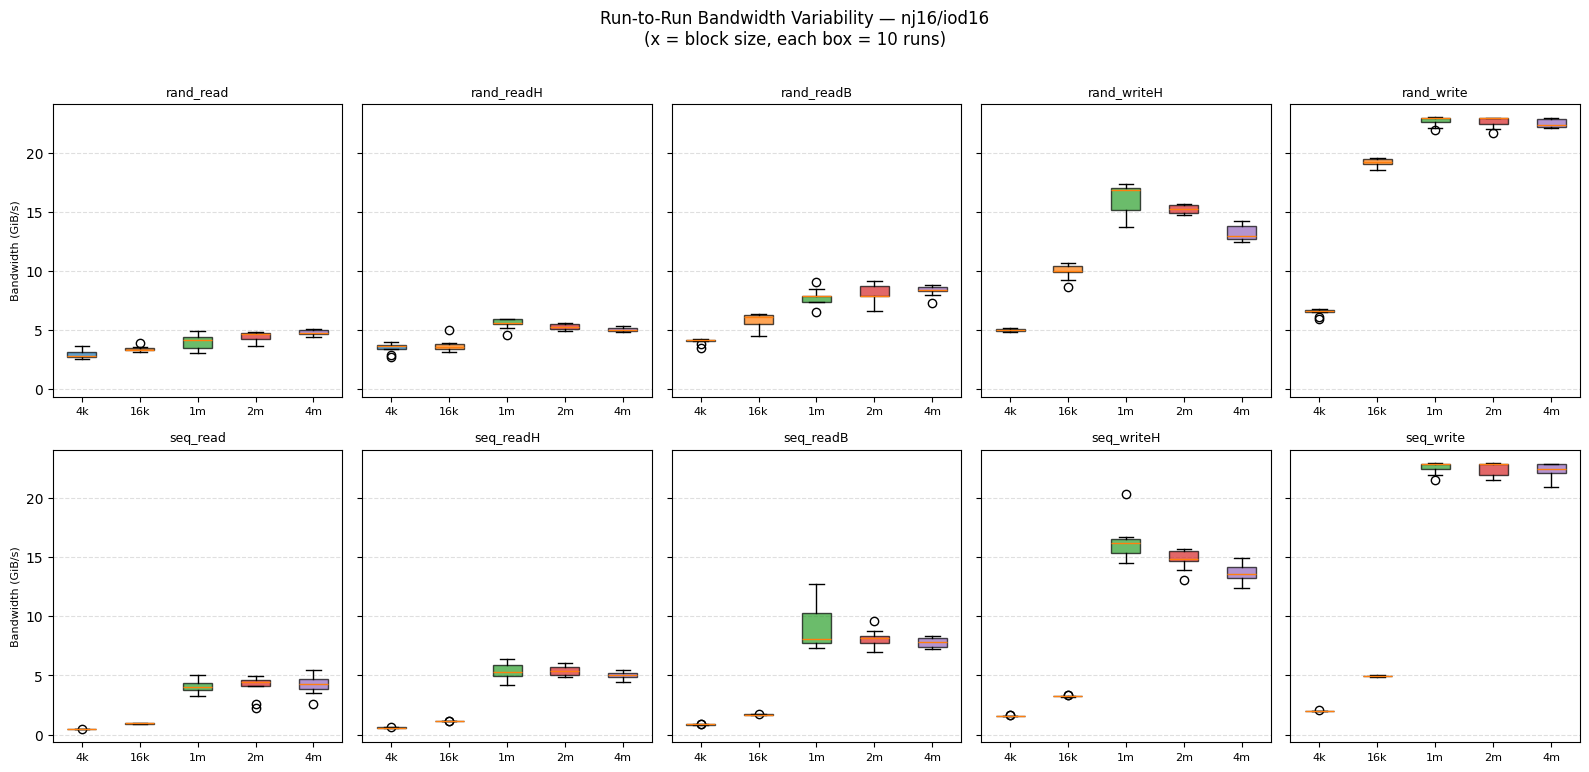

In [4]:

# Run-to-run bandwidth variability — nj16/iod16 only
# One subplot per pattern; x-axis = block sizes; shared y-axis
df16 = df[df["config"] == "nj16/iod16"]
bs_present  = [b for b in BS_ORDER if b in df16["block_size"].unique()]
pat_present = [p for p in PATTERN_ORDER if p in df16["pattern"].unique()]

n_pat = len(pat_present)
ncols = 5
nrows = (n_pat + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 3.8),
                         sharey=True, squeeze=False)

clrs = plt.cm.tab10.colors

for idx, pat in enumerate(pat_present):
    ax = axes[idx // ncols][idx % ncols]
    data_per_bs = [
        df16.loc[(df16["pattern"] == pat) & (df16["block_size"] == bs), "bw_GiBs"].values
        for bs in bs_present
    ]
    bp = ax.boxplot(data_per_bs, labels=bs_present, patch_artist=True, vert=True)
    for patch, clr in zip(bp["boxes"], clrs[:len(bs_present)]):
        patch.set_facecolor(clr)
        patch.set_alpha(0.7)
    ax.set_title(pat, fontsize=9)
    ax.tick_params(axis="x", labelsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    if idx % ncols == 0:
        ax.set_ylabel("Bandwidth (GiB/s)", fontsize=8)

# Hide unused axes
for idx in range(n_pat, nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

plt.suptitle("Run-to-Run Bandwidth Variability — nj16/iod16\n(x = block size, each box = 10 runs)",
             y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "variability_boxplot.pdf", dpi=150, bbox_inches="tight")
plt.show()


In [13]:

# CV% (std/mean × 100) for each pattern × block size — nj16/iod16
df16 = df[df["config"] == "nj16/iod16"]
cv_pivot = (
    df16.groupby(["pattern", "block_size"], observed=True)["bw_GiBs"]
    .agg(lambda x: x.std() / x.mean() * 100)
    .unstack("block_size")
    .reindex(
        index=[p for p in PATTERN_ORDER if p in df16["pattern"].unique()],
        columns=[b for b in BS_ORDER if b in df16["block_size"].unique()],
    )
)
display(cv_pivot.style
    .set_caption("Coefficient of Variation (%) of bandwidth — nj16/iod16")
    .format("{:.1f}%")
    .background_gradient(cmap="YlOrRd", axis=None)
)


block_size,4k,16k,1m,2m,4m
pattern,,,,,
rand_read,12.4%,6.7%,15.0%,8.5%,5.4%
rand_readH,11.5%,14.7%,7.6%,4.6%,3.2%
rand_readB,5.7%,12.6%,8.9%,10.3%,5.2%
rand_writeH,2.1%,6.4%,7.7%,2.4%,5.0%
rand_write,4.5%,1.8%,1.8%,2.2%,1.6%
seq_read,2.0%,1.2%,13.5%,22.8%,19.3%
seq_readH,2.0%,1.3%,12.6%,7.8%,7.0%
seq_readB,1.8%,1.6%,20.3%,9.1%,5.5%
seq_writeH,1.8%,1.4%,10.1%,5.6%,6.2%


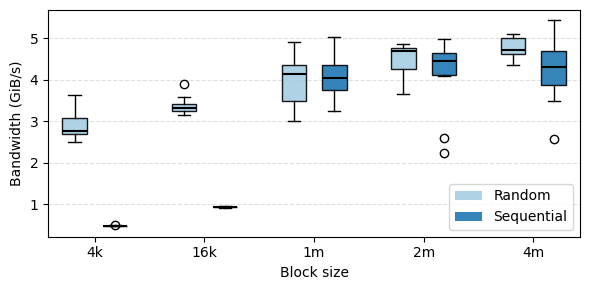

In [34]:

# Boxplot: rand_read vs seq_read — all block sizes — nj16/iod16 (publication figure)
from matplotlib.patches import Patch

ALL_BS  = [b for b in BS_ORDER if b in df16["block_size"].unique()]
ACCESS  = ["rand", "seq"]
C_RAND  = "#a6cee3"   # Paired light-blue
C_SEQ   = "#1f78b4"   # Paired dark-blue
GAP     = 0.7

fig, ax = plt.subplots(figsize=(6, 3))

positions, data, colors, group_centers = [], [], [], []
for g, bs in enumerate(ALL_BS):
    base = g * (len(ACCESS) + GAP)
    group_centers.append(base + 0.5)
    for acc, c in zip(ACCESS, [C_RAND, C_SEQ]):
        positions.append(base + ACCESS.index(acc))
        data.append(df16.loc[
            (df16["pattern"] == f"{acc}_read") & (df16["block_size"] == bs), "bw_GiBs"
        ].values)
        colors.append(c)

bp = ax.boxplot(data, positions=positions, patch_artist=True, widths=0.6,
                medianprops=dict(color="black", linewidth=1.5))
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.9)

ax.set_xticks(group_centers)
ax.set_xticklabels(ALL_BS, fontsize=10)
ax.set_xlabel("Block size", fontsize=10)
ax.set_ylabel("Bandwidth (GiB/s)", fontsize=10)
ax.set_xlim(positions[0] - 0.65, positions[-1] + 0.65)
ax.grid(axis="y", linestyle="--", alpha=0.4)

ax.legend(handles=[
    Patch(facecolor=C_RAND, alpha=0.9, label="Random"),
    Patch(facecolor=C_SEQ,  alpha=0.9, label="Sequential"),
], fontsize=10, loc="lower right")

# ax.set_title("Read-only Bandwidth Distribution (nj16/iod16, 10 runs each)", fontsize=10)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fio-read-boxplot.pdf", dpi=150, bbox_inches="tight")
plt.show()blob:vscode-webview://0ov37mdvdscs9nm0bs0d6d99ejl2sqhsdodb5d127diqn2j4mu8s/0634542c-3ac8-4809-8cf0-de158e179f40


### Variability Findings (nj16/iod16)

**Run counts:** Every combination of pattern × block size has exactly **10 runs**.

**Overall:** Median coefficient of variation (CV) across all 50 pattern×BS cells is **5.4%**
(mean 6.6%). Variability is strongly pattern- and block-size-dependent.

**By pattern (mean CV across block sizes):**

| Pattern | Mean CV (%) | Character |
|---|---|---|
| `seq_read`  | 11.8 | most variable |
| `rand_read` | 9.6  | |
| `rand_readB` | 8.5 | |
| `rand_readH` | 8.3 | |
| `seq_readB`  | 7.6 | |
| `seq_readH`  | 6.1 | |
| `seq_writeH` | 5.0 | |
| `rand_writeH`| 4.7 | |
| `rand_write` | 2.4 | |
| `seq_write`  | 2.2 | most stable |

Read-dominated patterns are roughly **4–5× more variable** than write-only patterns.
Write paths are deterministic (log-append to DRAM); read paths are sensitive to DRAM
cache state, which varies between back-to-back runs.

**By block size (mean CV across patterns):**

| Block size | Mean CV (%) |
|---|---|
| 1m  | 10.0 |
| 2m  | 7.6  |
| 4m  | 6.1  |
| 16k | 4.9  |
| 4k  | 4.6  |

1 MiB block size is the most variable because it sits at the crossover between
network-latency-limited and bandwidth-saturation regimes, making it sensitive to
server-side scheduling jitter. Very small blocks (4k/16k) and very large blocks (4m)
have more predictable behavior.

**Worst single cases:** `seq_read` at 2 m (CV=22.8%), `seq_readB` at 1 m (CV=20.3%),
`seq_read` at 4 m (CV=19.3%). All are large-block sequential-read scenarios where
DAOS server prefetch and DRAM cache hit rates fluctuate across runs.

**Most stable:** `seq_write` at 16k (CV=1.0%), `rand_write` at 4m/16k (CV≈1.6–1.8%).


## Mean/Max Latency (ms)

In [ ]:
pivot = (
    df[df["config"] == "nj16/iod16"]
    .pivot_table(index="pattern", columns="block_size", values="lat_mean_ms",
                 aggfunc="median", observed=True)
    .reindex(index=[p for p in PATTERN_ORDER if p in df["pattern"].unique()],
             columns=[b for b in BS_ORDER if b in df["block_size"].unique()])
)
display(pivot.round(3).style
    .set_caption("Median Mean Latency (ms) — nj16/iod16")
    .format("{:.3f}")
    .background_gradient(cmap="YlOrRd", axis=None)
)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for col_idx, (col, ylabel) in enumerate([
    ("lat_mean_ms", "Median Latency (ms)"),
    ("lat_max_ms",  "Median Max Latency (ms)"),
]):
    ax = axes[col_idx]
    x_ticks, _ = plot_metric(ax, col, "nj16/iod16")
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(BASE_OPS)
    ax.set_ylabel(ylabel)
    ax.set_title(f"nj16/iod16 — {ylabel}")
    if col_idx == 1:
        ax.legend(title="access / block size", loc="upper right", ncol=2, fontsize=7)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "latency-all-pattern.pdf", dpi=150)
plt.show()

## Bandwidth (GiB/s)

In [ ]:
OP_LABELS = ["Read-only", "Read-heavy", "Read-balanced", "Write-heavy", "Write-only"]

fig, ax = plt.subplots(figsize=(8, 3))
x_ticks, _ = plot_metric(ax, "bw_GiBs", "nj16/iod16")
ax.set_xticks(x_ticks)
ax.set_xticklabels(OP_LABELS, ha="center")
ax.set_ylabel("Bandwidth (GiB/s)")
ax.legend(title="Access pattern / fio block size (nj16/iod16)", loc="upper left", ncol=5, fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fio-bw-all-pattern-nj16-iod16.pdf", dpi=150)
plt.show()

In [ ]:
OP_SUFFIXES = ["read", "readH", "readB", "writeH", "write"]
OP_LABEL_MAP = {
    "read":   "Read-only",
    "readH":  "Read-heavy",
    "readB":  "Read-balanced",
    "writeH": "Write-heavy",
    "write":  "Write-only",
}

med = (
    df[df["config"] == "nj16/iod16"]
    .groupby(["block_size", "pattern"], observed=True)["bw_GiBs"]
    .median()
    .reset_index()
)

rows = []
for bs in BS_ORDER:
    if bs not in med["block_size"].values:
        continue
    for op in OP_SUFFIXES:
        rand_row = med[(med["block_size"] == bs) & (med["pattern"] == f"rand_{op}")]
        seq_row  = med[(med["block_size"] == bs) & (med["pattern"] == f"seq_{op}")]
        if rand_row.empty or seq_row.empty:
            continue
        r_bw = rand_row["bw_GiBs"].values[0]
        s_bw = seq_row["bw_GiBs"].values[0]
        rows.append(dict(
            workload    = OP_LABEL_MAP[op],
            block_size  = bs,
            rand_GiBs   = r_bw,
            seq_GiBs    = s_bw,
            rand_vs_seq = (r_bw / s_bw - 1) * 100,
        ))

comp = pd.DataFrame(rows)
comp["block_size"] = pd.Categorical(comp["block_size"], categories=BS_ORDER, ordered=True)
workload_order = [OP_LABEL_MAP[op] for op in OP_SUFFIXES]
bs_present = [b for b in BS_ORDER if b in comp["block_size"].cat.categories and
              b in comp["block_size"].values]

# Detailed table: rand bw, seq bw, ratio
detail = comp.set_index(["workload", "block_size"])[["rand_GiBs", "seq_GiBs", "rand_vs_seq"]]
detail = detail.unstack("block_size").reindex(workload_order, level=0)
detail.columns = pd.MultiIndex.from_tuples(
    [(metric, bs) for metric, bs in detail.columns],
    names=["metric", "block_size"]
)
col_order = [(m, b) for m in ["rand_GiBs", "seq_GiBs", "rand_vs_seq"] for b in bs_present
             if (m, b) in detail.columns]
detail = detail[col_order]

display(detail.style
    .set_caption(
        "Random vs Sequential — median bandwidth (GiB/s) and ratio [nj16/iod16]\n"
        "rand_vs_seq = (rand / seq − 1) × 100%; positive = random faster"
    )
    .format(lambda v: f"{v:.2f}", subset=[c for c in detail.columns if "rand_vs_seq" not in c[0]])
    .format(lambda v: f"{v:+.1f}%", subset=[c for c in detail.columns if "rand_vs_seq" in c[0]])
    .background_gradient(cmap="RdYlGn", axis=None,
                         subset=[c for c in detail.columns if "rand_vs_seq" in c[0]])
)

# Compact ratio-only pivot
pivot = (
    comp.pivot(index="workload", columns="block_size", values="rand_vs_seq")
    .reindex(index=workload_order, columns=bs_present)
)
display(pivot.style
    .set_caption("rand_vs_seq (%) summary — nj16/iod16  [positive = random faster]")
    .format("{:+.1f}%")
    .background_gradient(cmap="RdYlGn", axis=None)
)

## CPU Usage (usr / sys)

In [ ]:
cpu_rows = []
for fpath in sorted(RESULTS_DIR.glob("*.json")):
    m = re.search(r"fio_bs(\S+?)_nj(\d+)_iod(\d+)_", Path(fpath).name)
    bs, nj, iod = m.group(1), int(m.group(2)), int(m.group(3))
    cfg = f"nj{nj}/iod{iod}"
    with open(fpath) as f:
        try:
            d = json.load(f)
        except json.JSONDecodeError:
            print(f"Skipping invalid/empty JSON: {Path(fpath).name}")
            continue
    for job in d["jobs"]:
        if job["jobname"] == "prefill":
            continue
        cpu_rows.append(dict(
            block_size = bs,
            config     = cfg,
            pattern    = job["jobname"],
            usr_cpu    = job["usr_cpu"],
            sys_cpu    = job["sys_cpu"],
        ))

df_cpu = pd.DataFrame(cpu_rows)
df_cpu["block_size"] = pd.Categorical(df_cpu["block_size"], categories=BS_ORDER, ordered=True)
df_cpu["pattern"]    = pd.Categorical(df_cpu["pattern"],    categories=PATTERN_ORDER, ordered=True)

df_c = df_cpu[df_cpu["config"] == "nj16/iod16"]
pivot_usr = df_c.pivot_table(index="pattern", columns="block_size", values="usr_cpu", aggfunc="median")
pivot_sys = df_c.pivot_table(index="pattern", columns="block_size", values="sys_cpu", aggfunc="median")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for col_idx, (pivot, title, cmap) in enumerate([
    (pivot_usr, "User CPU (%) — nj16/iod16", "YlOrRd"),
    (pivot_sys, "Sys CPU (%) — nj16/iod16",  "Blues"),
]):
    ax = axes[col_idx]
    im = ax.imshow(pivot.values, aspect="auto", cmap=cmap,
                   vmin=pivot.values.min(), vmax=pivot.values.max())
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.85)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            ax.text(j, i, f"{pivot.values[i, j]:.1f}",
                    ha="center", va="center", fontsize=7.5,
                    color="black" if pivot.values[i, j] < pivot.values.max() * 0.75 else "white")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "cpu_usage.pdf", dpi=150)
plt.show()

## Actual Data Volume Transferred

Calculated from `io_bytes` in the fio JSON output (exact bytes, not BW × time).
Mixed patterns use `unified_rw_reporting=1` so only a combined total is available;
read/write split applies the nominal ratios (`readH`=80/20, `readB`=50/50, `writeH`=20/80).
Working set is 20 GiB/job × 16 jobs = **320 GiB**; each timed section runs 60 s.

In [ ]:
# Nominal read fraction per pattern (mixed patterns: unified_rw_reporting combines R+W)
READ_FRAC = {
    "rand_read":   1.0,  "seq_read":   1.0,
    "rand_readH":  0.8,  "seq_readH":  0.8,
    "rand_readB":  0.5,  "seq_readB":  0.5,
    "rand_writeH": 0.2,  "seq_writeH": 0.2,
    "rand_write":  0.0,  "seq_write":  0.0,
}

vol_rows = []
for fpath in sorted(RESULTS_DIR.glob("*.json")):
    m = re.search(r"fio_bs(\S+?)_nj(\d+)_iod(\d+)_", Path(fpath).name)
    if not m:
        continue
    bs = m.group(1)
    try:
        with open(fpath) as f:
            d = json.load(f)
    except Exception:
        continue

    for job in d["jobs"]:
        name = job["jobname"]
        if name not in READ_FRAC:
            continue
        if "mixed" in job:
            total_b   = job["mixed"]["io_bytes"]
            rf        = READ_FRAC[name]
            read_GiB  = total_b * rf       / 1024**3
            write_GiB = total_b * (1 - rf) / 1024**3
        else:
            read_GiB  = job["read"]["io_bytes"]  / 1024**3
            write_GiB = job["write"]["io_bytes"] / 1024**3

        vol_rows.append(dict(
            block_size=bs, pattern=name,
            read_GiB=read_GiB, write_GiB=write_GiB,
        ))

df_vol = pd.DataFrame(vol_rows)
df_vol["block_size"] = pd.Categorical(df_vol["block_size"], categories=BS_ORDER, ordered=True)
df_vol["pattern"]    = pd.Categorical(df_vol["pattern"],    categories=PATTERN_ORDER, ordered=True)

# ── Table 1: per-pattern × per-block-size (median across repeated runs) ──────
med_vol = (
    df_vol.groupby(["pattern", "block_size"], observed=True)[["read_GiB", "write_GiB"]]
    .median()
    .unstack("block_size")
)
med_vol.columns = pd.MultiIndex.from_tuples(
    [(col, bs) for col, bs in med_vol.columns], names=["metric", "block_size"]
)
col_order = [(metric, bs) for metric in ["read_GiB", "write_GiB"]
             for bs in BS_ORDER if (metric, bs) in med_vol.columns]
med_vol = med_vol.reindex(PATTERN_ORDER)[col_order]

display(med_vol.style
    .set_caption("Data transferred per section per run — GiB  (median over repeated runs)")
    .format("{:.0f}")
    .background_gradient(cmap="Blues", axis=None)
)

# ── Table 2: per-block-size totals across all 10 sections ────────────────────
per_bs = (
    df_vol.groupby(["block_size", "pattern"], observed=True)[["read_GiB", "write_GiB"]]
    .median()
    .groupby("block_size")
    .sum()
)
per_bs["total_GiB"] = per_bs["read_GiB"] + per_bs["write_GiB"]

display(per_bs.style
    .set_caption("Total data per fio invocation (all 10 sections, one block size) — GiB")
    .format("{:.0f}")
    .background_gradient(cmap="Greens", axis=None)
)

# ── Grand summary ─────────────────────────────────────────────────────────────
gt = per_bs.mean()
print(f"Average per fio run (mean across the {len(per_bs)} block sizes):")
print(f"  Read  : {gt['read_GiB']:.0f} GiB  ({gt['read_GiB']/1024:.2f} TiB)")
print(f"  Write : {gt['write_GiB']:.0f} GiB  ({gt['write_GiB']/1024:.2f} TiB)")
print(f"  Total : {gt['total_GiB']:.0f} GiB  ({gt['total_GiB']/1024:.2f} TiB)")

ro_per_section = (
    df_vol[df_vol["pattern"].isin(["rand_read", "seq_read"])]
    .groupby(["pattern", "block_size"], observed=True)["read_GiB"]
    .median()
    .mean()
)
print(f"\nRead-only sections average {ro_per_section:.0f} GiB per 60 s section"
      f" (working set = 320 GiB → {ro_per_section/320*100:.0f}% of one full pass).")